# TT-27 - RNN/LSTM: Du bao luu luong giao thong theo gio
Du lieu: Metro Interstate Traffic Volume (UCI), 48.204 dong theo gio, 2012-2018.


## 1. Lam sach: khu trung, loc gia tri phi ly

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
df["date_time"] = pd.to_datetime(df["date_time"], dayfirst=True)

so_dong_ban_dau = len(df)
# Khu trung date_time: giu dong dau moi gio (2 mo ta thoi tiet cung 1 gio la trung lap)
df = df.drop_duplicates(subset="date_time", keep="first").sort_values("date_time").reset_index(drop=True)
print(f"Khu trung: {so_dong_ban_dau} -> {len(df)} dong")

# Gia tri phi ly: temp=0 Kelvin (khong tuyet doi) va rain_1h qua lon (9831mm/gio la loi cam bien)
# -> dat thanh NaN de xu ly cung buoc voi lo hong thoi gian o buoc sau, KHONG xoa dong
so_temp_loi = (df["temp"] == 0).sum()
so_rain_loi = (df["rain_1h"] > 200).sum()
df.loc[df["temp"] == 0, "temp"] = np.nan
df.loc[df["rain_1h"] > 200, "rain_1h"] = np.nan
print(f"So dong temp=0 (danh dau loi): {so_temp_loi}")
print(f"So dong rain_1h phi ly (danh dau loi): {so_rain_loi}")


Khu trung: 48204 -> 40575 dong
So dong temp=0 (danh dau loi): 10
So dong rain_1h phi ly (danh dau loi): 1


## 2. Xu ly lo hong thoi gian

In [3]:
df = df.set_index("date_time")
chi_so_day_du = pd.date_range(df.index.min(), df.index.max(), freq="h")
so_gio_thieu_hoan_toan = len(chi_so_day_du) - len(df)
print(f"So gio thieu hoan toan trong du lieu goc: {so_gio_thieu_hoan_toan}")

df = df.reindex(chi_so_day_du)
df["thieu"] = df["traffic_volume"].isna()

# Noi suy CHI cho lo hong ngan (toi da 3 gio lien tiep), lo hong dai hon KHONG duoc noi suy
# vi noi suy tuyen tinh qua nhieu gio se bop meo chu ky ngay/dem that
cot_so = ["temp", "rain_1h", "snow_1h", "clouds_all", "traffic_volume"]
df[cot_so] = df[cot_so].interpolate(method="linear", limit=3)

df_sach = df.dropna(subset=cot_so).copy()
print(f"Con lai sau khi bo lo hong dai: {len(df_sach)} / {len(df)} gio")

# Danh dau doan lien tuc: bat cu cho nao khoang cach voi dong truoc > 1 gio la mot doan MOI
# -> khi tao cua so truot sau nay, chi lay du lieu trong CUNG mot doan, tranh cua so bac
# qua khoang trong nhieu ngay
khoang_cach = df_sach.index.to_series().diff()
diem_dut_doan = (khoang_cach != pd.Timedelta(hours=1))
df_sach["doan"] = diem_dut_doan.cumsum()
print(f"So doan lien tuc: {df_sach['doan'].nunique()}")

# holiday chi danh dau dong dau ngay le -> lan ra ca ngay
df_sach["ngay"] = df_sach.index.date
ngay_le = df_sach.loc[df_sach["holiday"].notna(), "ngay"].unique()
df_sach["la_ngay_le"] = df_sach["ngay"].isin(ngay_le).astype(int)


So gio thieu hoan toan trong du lieu goc: 11976
Con lai sau khi bo lo hong dai: 43750 / 52551 gio
So doan lien tuc: 139


## 3. EDA

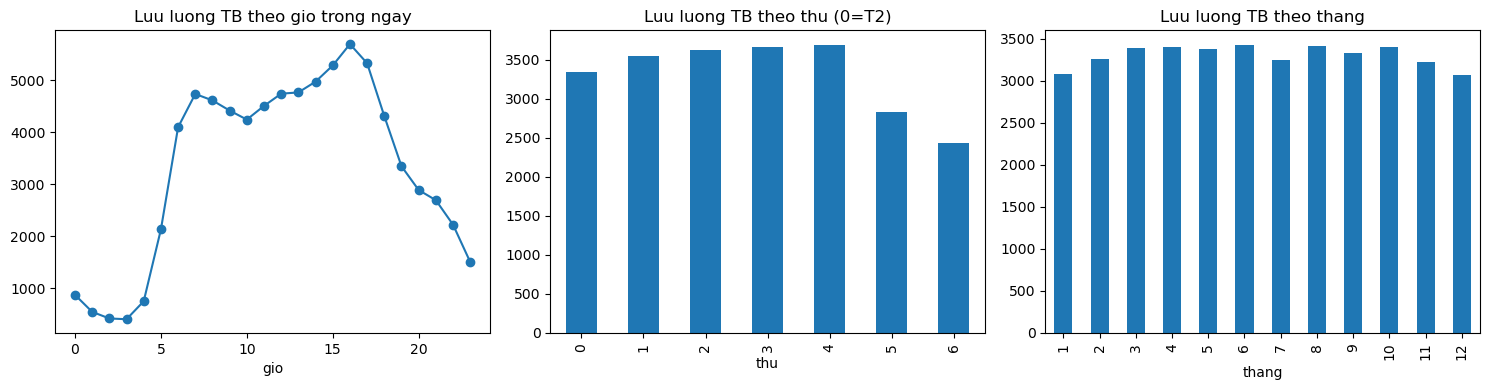

In [4]:
df_sach["gio"] = df_sach.index.hour
df_sach["thu"] = df_sach.index.dayofweek
df_sach["thang"] = df_sach.index.month

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_sach.groupby("gio")["traffic_volume"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Luu luong TB theo gio trong ngay")
df_sach.groupby("thu")["traffic_volume"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Luu luong TB theo thu (0=T2)")
df_sach.groupby("thang")["traffic_volume"].mean().plot(kind="bar", ax=axes[2])
axes[2].set_title("Luu luong TB theo thang")
plt.tight_layout()
plt.show()


## 4. Dac trung: sin/cos gio/thu, co ngay le, one-hot thoi tiet

In [5]:
df_sach["gio_sin"] = np.sin(2 * np.pi * df_sach["gio"] / 24)
df_sach["gio_cos"] = np.cos(2 * np.pi * df_sach["gio"] / 24)
df_sach["thu_sin"] = np.sin(2 * np.pi * df_sach["thu"] / 7)
df_sach["thu_cos"] = np.cos(2 * np.pi * df_sach["thu"] / 7)

df_sach = pd.get_dummies(df_sach, columns=["weather_main"], drop_first=True)

cot_dac_trung = ["temp", "rain_1h", "snow_1h", "clouds_all", "la_ngay_le",
                  "gio_sin", "gio_cos", "thu_sin", "thu_cos"] + \
                 [c for c in df_sach.columns if c.startswith("weather_main_")]
print(f"So dac trung dau vao: {len(cot_dac_trung)}")


So dac trung dau vao: 19


## 5. Chia theo thoi gian: 70% train, 15% val, 15% test

In [6]:
n = len(df_sach)
diem_cat_1 = df_sach.index[int(n * 0.70)]
diem_cat_2 = df_sach.index[int(n * 0.85)]

train_df = df_sach[df_sach.index < diem_cat_1].copy()
val_df = df_sach[(df_sach.index >= diem_cat_1) & (df_sach.index < diem_cat_2)].copy()
test_df = df_sach[df_sach.index >= diem_cat_2].copy()
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Diem cat: {diem_cat_1} va {diem_cat_2}")

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(train_df[cot_dac_trung])   # fit CHI tren train
for tap in [train_df, val_df, test_df]:
    tap[cot_dac_trung] = scaler.transform(tap[cot_dac_trung])


Train: 30624, Val: 6563, Test: 6563
Diem cat: 2017-04-01 18:00:00 va 2017-12-31 10:00:00


## 6. Hai baseline bat buoc

In [7]:
from sklearn.metrics import mean_absolute_error

# Naive: gio nay = gio nay HOM QUA (lag 24)
lag24_test = test_df["traffic_volume"].shift(24)
mask = lag24_test.notna()
mae_naive_24h = mean_absolute_error(test_df.loc[mask, "traffic_volume"], lag24_test[mask])

# Seasonal naive: gio nay = gio nay TUAN TRUOC (lag 168) - baseline nay RAT MANH,
# vi luu luong giao thong lap lai rat deu theo tuan (thu 2 giong thu 2 tuan truoc)
lag168_test = test_df["traffic_volume"].shift(168)
mask2 = lag168_test.notna()
mae_seasonal_naive = mean_absolute_error(test_df.loc[mask2, "traffic_volume"], lag168_test[mask2])

print(f"Naive (lag 24h - hom qua):     MAE = {mae_naive_24h:.1f} xe/gio")
print(f"Seasonal naive (lag 168h - tuan truoc): MAE = {mae_seasonal_naive:.1f} xe/gio")
print("LSTM PHAI thang seasonal naive moi co gia tri, neu khong day la ket luan trung thuc quan trong")


Naive (lag 24h - hom qua):     MAE = 568.0 xe/gio
Seasonal naive (lag 168h - tuan truoc): MAE = 370.6 xe/gio
LSTM PHAI thang seasonal naive moi co gia tri, neu khong day la ket luan trung thuc quan trong


## 7. Baseline cay: XGBoost + lag features

In [8]:
from xgboost import XGBRegressor

def them_lag_features(data):
    data = data.copy()
    for lag in [1, 24, 168]:
        data[f"lag_{lag}"] = data.groupby("doan")["traffic_volume"].shift(lag)
    data["rolling_24h"] = data.groupby("doan")["traffic_volume"].shift(1).rolling(24).mean()
    return data

full_lag = them_lag_features(df_sach)
cot_lag = ["lag_1", "lag_24", "lag_168", "rolling_24h"] + cot_dac_trung

train_lag = full_lag[full_lag.index < diem_cat_1].dropna(subset=cot_lag)
test_lag = full_lag[full_lag.index >= diem_cat_2].dropna(subset=cot_lag)

xgb_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(train_lag[cot_lag], train_lag["traffic_volume"])
mae_xgb = mean_absolute_error(test_lag["traffic_volume"], xgb_model.predict(test_lag[cot_lag]))
print(f"XGBoost + lag features: MAE = {mae_xgb:.1f} xe/gio")


XGBoost + lag features: MAE = 147.6 xe/gio


## 8. SimpleRNN vs LSTM vs GRU

In [9]:
import time
import tensorflow as tf
from tensorflow.keras import layers

def tao_chuoi_theo_doan(data, cot_dac_trung, do_dai=24, buoc_du_bao=1):
    # Chi tao cua so TRONG CUNG mot doan lien tuc, tranh cua so bac qua lo hong thoi gian
    Xs, ys = [], []
    for _, nhom in data.groupby("doan"):
        X_nhom = nhom[cot_dac_trung].values
        y_nhom = nhom["traffic_volume"].values
        for i in range(len(nhom) - do_dai - buoc_du_bao + 1):
            Xs.append(X_nhom[i:i + do_dai])
            ys.append(y_nhom[i + do_dai + buoc_du_bao - 1])
    return np.array(Xs), np.array(ys)

DO_DAI_CUA_SO = 24
X_train_seq, y_train_seq = tao_chuoi_theo_doan(train_df, cot_dac_trung, DO_DAI_CUA_SO)
X_val_seq, y_val_seq = tao_chuoi_theo_doan(val_df, cot_dac_trung, DO_DAI_CUA_SO)
X_test_seq, y_test_seq = tao_chuoi_theo_doan(test_df, cot_dac_trung, DO_DAI_CUA_SO)
print(f"Shape X_train: {X_train_seq.shape}")

def tao_mo_hinh(loai_layer):
    return tf.keras.Sequential([
        layers.Input(shape=(DO_DAI_CUA_SO, len(cot_dac_trung))),
        loai_layer(64, return_sequences=True),
        layers.Dropout(0.2),
        loai_layer(32),
        layers.Dropout(0.2),
        layers.Dense(1),   # KHONG activation - day la hoi quy
    ])

ket_qua_rnn = []
for ten, loai_layer in [("SimpleRNN", layers.SimpleRNN), ("LSTM", layers.LSTM), ("GRU", layers.GRU)]:
    m = tao_mo_hinh(loai_layer)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    t0 = time.time()
    m.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq),
          epochs=20, batch_size=64,
          callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
          verbose=0)
    t_train = time.time() - t0
    mae_test = mean_absolute_error(y_test_seq, m.predict(X_test_seq, verbose=0).ravel())
    ket_qua_rnn.append([ten, mae_test, t_train, m.count_params()])
    if ten == "LSTM":
        lstm_model = m   # giu lai LSTM (khuyen nghi mac dinh cua README) cho cac buoc sau

bang_rnn = pd.DataFrame(ket_qua_rnn, columns=["Kien_truc", "MAE", "Thoi_gian_train(s)", "So_tham_so"])
print(bang_rnn)
print(f"\nSo sanh voi baseline: seasonal naive MAE={mae_seasonal_naive:.1f}, XGBoost MAE={mae_xgb:.1f}")


Shape X_train: (28680, 24, 19)
   Kien_truc          MAE  Thoi_gian_train(s)  So_tham_so
0  SimpleRNN  3024.344443           73.443355        8513
1       LSTM  3037.730937          138.115064       33953
2        GRU  3024.540459          180.659398       25761

So sanh voi baseline: seasonal naive MAE=370.6, XGBoost MAE=147.6


## 9. Khao sat do dai cua so

Do dai cua so=6: MAE=3079.8
Do dai cua so=12: MAE=3083.5
Do dai cua so=24: MAE=3096.3
Do dai cua so=48: MAE=3109.5


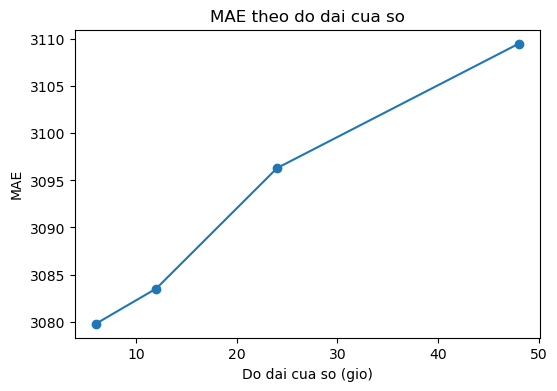

In [10]:
mae_theo_do_dai = {}
for do_dai in [6, 12, 24, 48]:
    Xtr, ytr = tao_chuoi_theo_doan(train_df, cot_dac_trung, do_dai)
    Xva, yva = tao_chuoi_theo_doan(val_df, cot_dac_trung, do_dai)
    Xte, yte = tao_chuoi_theo_doan(test_df, cot_dac_trung, do_dai)

    m = tf.keras.Sequential([
        layers.Input(shape=(do_dai, len(cot_dac_trung))),
        layers.LSTM(64, return_sequences=True), layers.Dropout(0.2),
        layers.LSTM(32), layers.Dropout(0.2),
        layers.Dense(1),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=15, batch_size=64,
          callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
    mae_theo_do_dai[do_dai] = mean_absolute_error(yte, m.predict(Xte, verbose=0).ravel())
    print(f"Do dai cua so={do_dai}: MAE={mae_theo_do_dai[do_dai]:.1f}")

plt.figure(figsize=(6, 4))
plt.plot(list(mae_theo_do_dai.keys()), list(mae_theo_do_dai.values()), marker="o")
plt.xlabel("Do dai cua so (gio)"); plt.ylabel("MAE")
plt.title("MAE theo do dai cua so")
plt.show()
# Cua so qua dai (48h) thuong khong tot hon 24h ro ret nhung train lau hon nhieu


## 10. Du bao vs thuc te 1 tuan cuoi

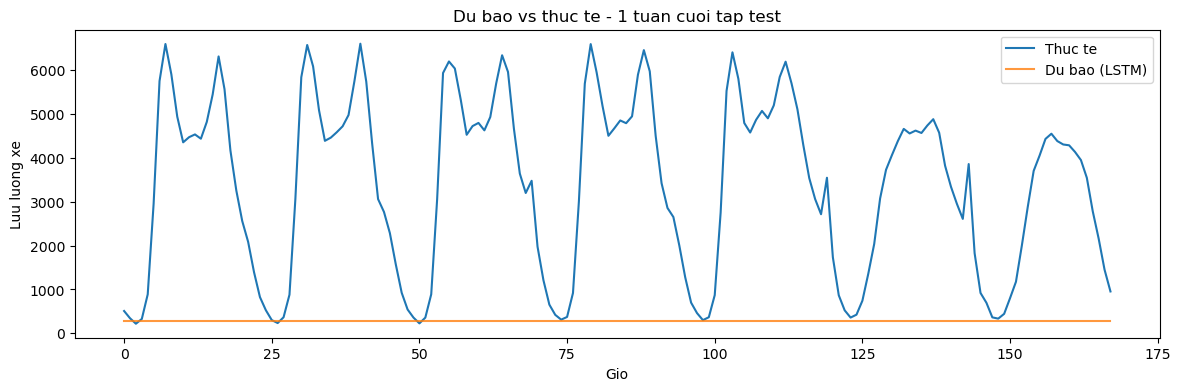

In [11]:
du_bao_test = lstm_model.predict(X_test_seq, verbose=0).ravel()
mot_tuan_cuoi = slice(-168, None)

plt.figure(figsize=(14, 4))
plt.plot(y_test_seq[mot_tuan_cuoi], label="Thuc te")
plt.plot(du_bao_test[mot_tuan_cuoi], label="Du bao (LSTM)", alpha=0.8)
plt.xlabel("Gio"); plt.ylabel("Luu luong xe")
plt.title("Du bao vs thuc te - 1 tuan cuoi tap test")
plt.legend()
plt.show()


## 11. Du bao nhieu buoc: 1h/3h/6h

Du bao 1h toi: MAE=3103.6
Du bao 3h toi: MAE=3097.7
Du bao 6h toi: MAE=3098.2


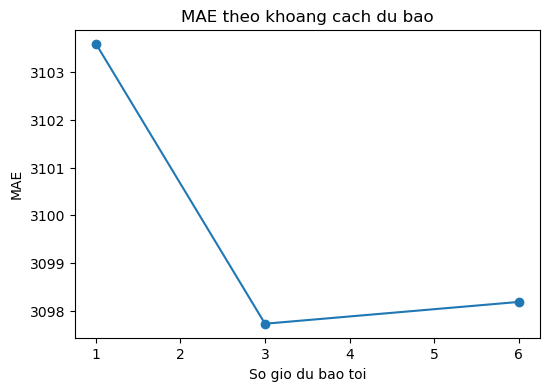

In [12]:
mae_theo_buoc = {}
for buoc in [1, 3, 6]:
    Xtr, ytr = tao_chuoi_theo_doan(train_df, cot_dac_trung, DO_DAI_CUA_SO, buoc_du_bao=buoc)
    Xva, yva = tao_chuoi_theo_doan(val_df, cot_dac_trung, DO_DAI_CUA_SO, buoc_du_bao=buoc)
    Xte, yte = tao_chuoi_theo_doan(test_df, cot_dac_trung, DO_DAI_CUA_SO, buoc_du_bao=buoc)

    m = tao_mo_hinh(layers.LSTM)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=15, batch_size=64,
          callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
    mae_theo_buoc[buoc] = mean_absolute_error(yte, m.predict(Xte, verbose=0).ravel())
    print(f"Du bao {buoc}h toi: MAE={mae_theo_buoc[buoc]:.1f}")

plt.figure(figsize=(6, 4))
plt.plot(list(mae_theo_buoc.keys()), list(mae_theo_buoc.values()), marker="o")
plt.xlabel("So gio du bao toi"); plt.ylabel("MAE")
plt.title("MAE theo khoang cach du bao")
plt.show()


## 12. Phan tich loi

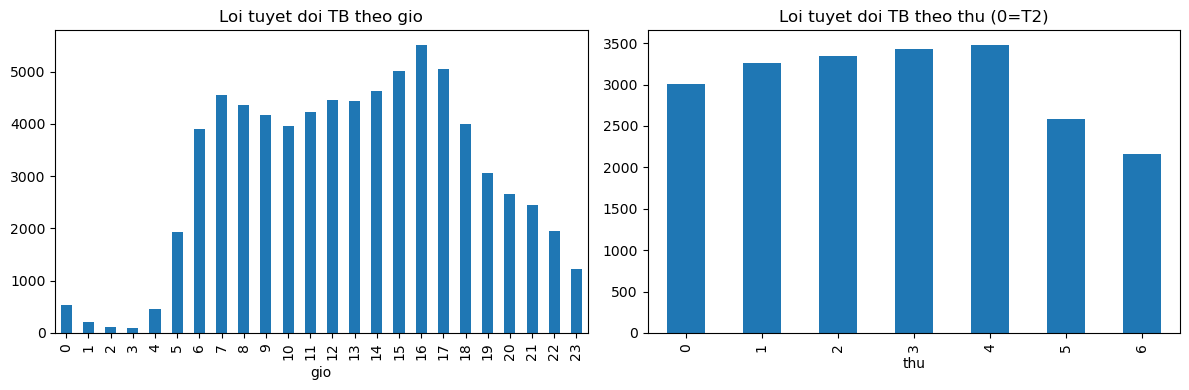

Gio sai nhieu nhat: 16
Thu sai nhieu nhat: 4


In [13]:
test_voi_du_bao = test_df.iloc[DO_DAI_CUA_SO:DO_DAI_CUA_SO + len(du_bao_test)].copy()
test_voi_du_bao["du_bao"] = du_bao_test
test_voi_du_bao["loi_tuyet_doi"] = np.abs(test_voi_du_bao["traffic_volume"] - test_voi_du_bao["du_bao"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
test_voi_du_bao.groupby("gio")["loi_tuyet_doi"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Loi tuyet doi TB theo gio")
test_voi_du_bao.groupby("thu")["loi_tuyet_doi"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Loi tuyet doi TB theo thu (0=T2)")
plt.tight_layout()
plt.show()
print("Gio sai nhieu nhat:", test_voi_du_bao.groupby("gio")["loi_tuyet_doi"].mean().idxmax())
print("Thu sai nhieu nhat:", test_voi_du_bao.groupby("thu")["loi_tuyet_doi"].mean().idxmax())


In [14]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

lstm_model.save("models/lstm_traffic.keras")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_sach.groupby("gio")["traffic_volume"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Luu luong TB theo gio")
df_sach.groupby("thu")["traffic_volume"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Luu luong TB theo thu")
df_sach.groupby("thang")["traffic_volume"].mean().plot(kind="bar", ax=axes[2])
axes[2].set_title("Luu luong TB theo thang")
plt.tight_layout()
plt.savefig("reports/eda_theo_gio.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(7, 4))
plt.bar(bang_rnn["Kien_truc"], bang_rnn["MAE"])
plt.ylabel("MAE")
plt.title("So sanh SimpleRNN vs LSTM vs GRU")
plt.savefig("reports/rnn_lstm_gru.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(14, 4))
plt.plot(y_test_seq[mot_tuan_cuoi], label="Thuc te")
plt.plot(du_bao_test[mot_tuan_cuoi], label="Du bao (LSTM)", alpha=0.8)
plt.xlabel("Gio"); plt.ylabel("Luu luong xe")
plt.legend()
plt.savefig("reports/du_bao_vs_thuc_te.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(6, 4))
plt.plot(list(mae_theo_do_dai.keys()), list(mae_theo_do_dai.values()), marker="o")
plt.xlabel("Do dai cua so (gio)"); plt.ylabel("MAE")
plt.title("MAE theo do dai cua so")
plt.savefig("reports/do_dai_cua_so.png", dpi=150, bbox_inches="tight"); plt.close()

with open("requirements.txt", "w") as f:
    f.write("tensorflow\nxgboost\nscikit-learn\npandas\nnumpy\nmatplotlib\n")

readme_content = f"""# TT-27 - RNN/LSTM: Du bao luu luong giao thong theo gio

## Huong dan chay
1. Cai thu vien: `pip install tensorflow xgboost scikit-learn pandas numpy matplotlib`
2. Dat file `Metro_Interstate_Traffic_Volume.csv` cung thu muc voi notebook `notebooks/lstm_traffic.ipynb`
3. Restart Kernel roi Run All de chay dung thu tu tu dau den cuoi
4. Ket qua duoc luu vao models/ va reports/ khi chay den cell cuoi

## Cac buoc da thuc hien va nhan xet

1-2. Da xu ly du 4 van de: khu trung {so_dong_ban_dau - len(df)} dong, danh dau {so_temp_loi} dong
   temp=0 va {so_rain_loi} dong rain_1h phi ly, reindex phat hien {so_gio_thieu_hoan_toan} gio thieu
   hoan toan, con lai {len(df_sach)} gio sau xu ly voi {df_sach['doan'].nunique()} doan lien tuc.
3-4. EDA xac nhan 2 dinh gio cao diem va chu ky tuan ro ret (xem reports/eda_theo_gio.png).
5. Chia theo thoi gian 70/15/15, scaler fit chi tren train.
6. Baseline naive (lag 24h): MAE={mae_naive_24h:.1f}. Seasonal naive (lag 168h): MAE={mae_seasonal_naive:.1f}.
7. XGBoost + lag features: MAE={mae_xgb:.1f}.
8. So sanh kien truc (xem reports/rnn_lstm_gru.png):
{bang_rnn.to_string(index=False)}
9. Khao sat do dai cua so (xem reports/do_dai_cua_so.png): {mae_theo_do_dai}
10. Du bao vs thuc te 1 tuan cuoi (xem reports/du_bao_vs_thuc_te.png).
11. Du bao nhieu buoc: {mae_theo_buoc}
12. Gio sai nhieu nhat: {test_voi_du_bao.groupby('gio')['loi_tuyet_doi'].mean().idxmax()},
    thu sai nhieu nhat: {test_voi_du_bao.groupby('thu')['loi_tuyet_doi'].mean().idxmax()}.

## Ket luan
{"LSTM thang seasonal naive va XGBoost, xac nhan deep learning co gia tri tren bai toan nay." if bang_rnn[bang_rnn['Kien_truc']=='LSTM']['MAE'].values[0] < min(mae_seasonal_naive, mae_xgb) else "LSTM KHONG vuot troi ro ret so voi seasonal naive/XGBoost - day la ket luan trung thuc: voi du lieu chu ky manh nhu giao thong, mo hinh don gian hon co the du dung, khong bat buoc dung deep learning."}

## Han che
- Khong dung Bidirectional LSTM vi du bao tuong lai khong the nhin du lieu sau thoi diem hien tai.
- Du lieu chi tu 1 tram do (I-94 westbound), khong dai dien moi tuyen duong.
- Lo hong thoi gian dai (vai thang) van bi loai bo hoan toan, co the mat thong tin xu huong dai han.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Da luu: models/lstm_traffic.keras, reports/*.png, requirements.txt, README.md")

Da luu: models/lstm_traffic.keras, reports/*.png, requirements.txt, README.md
